# Reddit comments (ML-ready) EDA

`reddit_comments_ml_ready.csv` with `clean_text`, `label`, and simple metadata columns.

In [1]:
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd

_HERE = Path.cwd().resolve()
if (_HERE / "data" / "datasets").is_dir():
    PROJECT_ROOT = _HERE
elif (_HERE.parent / "data" / "datasets").is_dir():
    PROJECT_ROOT = _HERE.parent
else:
    raise FileNotFoundError("Run from repo root or notebooks/")

sys.path.insert(0, str(PROJECT_ROOT / "notebooks"))
import eda_helpers as edh

pd.set_option("display.max_colwidth", 100)

try:
    from IPython.display import display
except ImportError:
    display = print

print("PROJECT_ROOT:", PROJECT_ROOT)


PROJECT_ROOT: /Users/deepakmurali/Projects/Brand-Perception-and-Sentiment-Analysis


## Load

In [2]:
path = edh.datasets_root(PROJECT_ROOT) / "reddit_comments" / "reddit_comments_ml_ready.csv"
df = edh.read_csv_safe(path)
print("shape:", df.shape)
print("columns:", list(df.columns))
display(df.head())
print("\nnulls:\n", df.isna().sum())
print("dup rows:", int(df.duplicated().sum()))


shape: (1533145, 4)
columns: ['clean_text', 'label', 'word_count', 'avg_word_length']


,clean_text,label,word_count,avg_word_length
0,switchfoot a thats a bummer you shoulda got david carr of third day to do it d,0,17,4.588235
1,is upset that he cant update his facebook by texting it and might cry as a result school today a...,0,21,4.952381
2,kenichan i dived many times for the ball managed to save the rest go out of bounds,0,17,4.823529
3,my whole body feels itchy and like its on fire,0,10,4.600000
4,nationwideclass no its not behaving at all im mad why am i here because i cant see you all over ...,0,21,4.809524



nulls:
 clean_text         0
label              0
word_count         0
avg_word_length    0
dtype: int64
dup rows: 0


## Labels

Inspect unique values to see if binary or multi-class. **Note:** This file can be **block-sorted** (many rows of `0` then `4`), so viewing only the first few rows may show **one class** until you run `value_counts` on the **full** loaded frame.

label
0    765261
4    767884
Name: count, dtype: int64
unique: [0, 4]
Labels 0 and 4 only in sample: matches Sentiment140-style neg (0) / pos (4); file may be block-sorted—scan full CSV for class 2 (neutral).


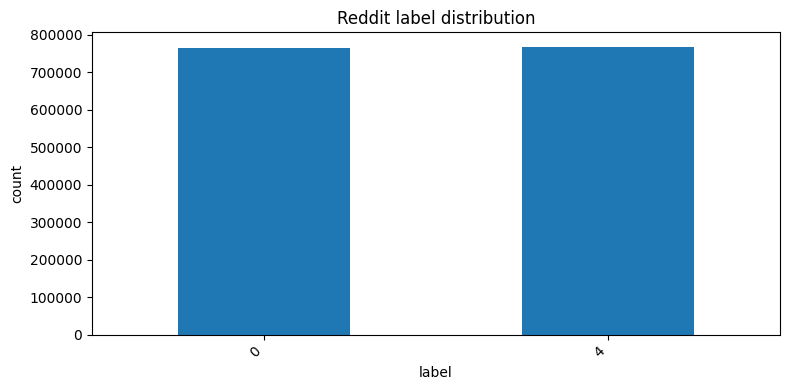

In [3]:
vc = df["label"].value_counts().sort_index()
print(vc)
print("unique:", sorted(df["label"].dropna().unique().tolist()))
print(edh.interpret_reddit_labels(df["label"].dropna().unique().tolist()))
edh.plot_label_counts(vc, "Reddit label distribution")


## Metadata columns

In [4]:
if "word_count" in df.columns:
    print(df[["word_count", "avg_word_length"]].describe())


         word_count  avg_word_length
count  1.533145e+06     1.533145e+06
mean   1.323167e+01     5.367837e+00
std    6.667877e+00     9.630179e-01
min    1.000000e+00     2.428571e+00
25%    8.000000e+00     4.800000e+00
50%    1.200000e+01     5.217391e+00
75%    1.800000e+01     5.750000e+00
max    4.100000e+01     1.250000e+02


## Text length (clean_text)

words mean/median: 13.231668889765809 12.0


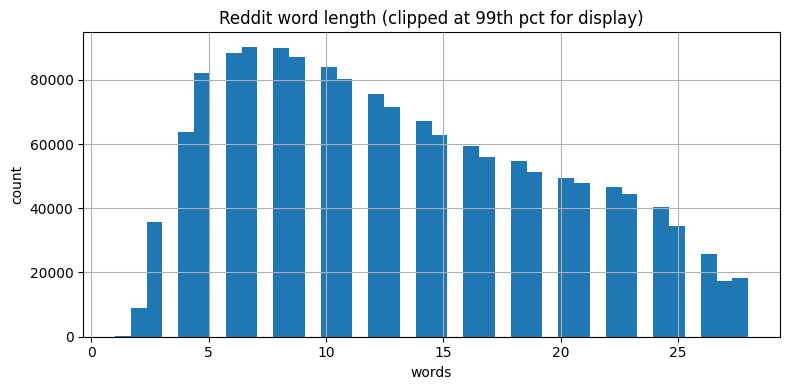

In [5]:
char_len, word_len = edh.char_word_lengths(df["clean_text"])
print("words mean/median:", float(word_len.mean()), float(word_len.median()))
edh.plot_hist_length(word_len, "Reddit word length", "words")


## Suspicious rows

In [6]:
char_len, word_len = edh.char_word_lengths(df["clean_text"])
print("≤2 words %:", 100.0 * (word_len <= 2).mean())
print("dup texts %:", edh.duplicate_text_pct(df["clean_text"]))


≤2 words %: 0.5972037869868799
dup texts %: 0.0


## Columns to keep for training

- **text**: `clean_text` (already normalized).
- **label**: after confirming semantics.
- Optional: drop `word_count` / `avg_word_length` if recomputing features.

In [7]:
summary = {
    "dataset": "reddit_ml_ready",
    "row_count": int(len(df)),
    "text_column": "clean_text",
    "label_column": "label",
    "label_space": str(sorted(df["label"].dropna().unique().tolist())),
    "avg_word_count": float(word_len.mean()),
    "median_word_count": float(word_len.median()),
    "duplicate_text_pct": edh.duplicate_text_pct(df["clean_text"]),
    "null_pct": edh.null_fraction_df(df) * 100.0,
    "preprocessing": "Confirm 0/1 meaning; map to 3-class if needed; keep clean_text + label.",
}
path = edh.save_eda_summary("reddit_ml_ready", summary, PROJECT_ROOT)
print("Saved:", path)


Saved: /Users/deepakmurali/Projects/Brand-Perception-and-Sentiment-Analysis/data/processed/eda_summaries/reddit_ml_ready.json
